In [1]:

# Structured Analysis Plan for M₄ Structure Evolution in L(s,χ)
# =================================================================

plan = """
STEP 1: IMPLEMENT L(s,χ) FOR COMPLEX CHARACTER MOD 5
 1.1: Define character χ mod 5 of order 4 (primitive character)
 1.2: Implement coefficient function a_n = χ(n)
 1.3: Validate multiplicativity and basic properties
 
STEP 2: IMPLEMENT DIRICHLET POLYNOMIAL EVALUATION
 2.1: Implement Kahan compensated summation for complex arithmetic
 2.2: Create function to evaluate D_F(t; N) = Σ_{n=1}^N χ(n)/n^{1/2+it}
 2.3: Validate with spot checks
 
STEP 3: FOURTH MOMENT DECOMPOSITION FRAMEWORK
 3.1: Implement ω-class decomposition S_k = Σ_{Ω(n)=k} a_n/n^{1/2+it}
 3.2: Compute M₄(t) = |D_F(t;N)|⁴
 3.3: Expand to M₄ = Σ_{j,k,l,m} S_j S̄_k S_l S̄_m
 3.4: Implement r40 classification (5 term types based on index patterns)
 
STEP 4: MULTI-SCALE ANALYSIS ACROSS N ∈ {10⁴, 10⁵, 10⁶}
 4.1: For each N:
 - Evaluate on 500-point grid in t ∈ [N, 2N]
 - Compute M₄(t) and decomposition at each point
 - Identify top 10% of M₄ values
 - Average term type contributions
 4.2: Track omega_values array (pre-computed for N=10⁶, generate for 10⁴ and 10⁵)
 
STEP 5: MONOTONICITY ANALYSIS
 5.1: Compare term type percentages across N values
 5.2: Compare average M₄ magnitudes
 5.3: Test for monotonic evolution vs. N=10⁵ anomaly
 5.4: Generate summary table and final visualization

STATISTICAL METHODS:
 - Descriptive statistics for M₄ distributions
 - Percentage decomposition analysis
 - Direct comparison with r53 results for L(s, χ₃)

EXPECTED LIMITATIONS:
 - Computational cost increases with N
 - Kahan summation required for precision but slower
 - Need to generate ω values for N=10⁴ and 10⁵
"""

print(plan)



STEP 1: IMPLEMENT L(s,χ) FOR COMPLEX CHARACTER MOD 5
 1.1: Define character χ mod 5 of order 4 (primitive character)
 1.2: Implement coefficient function a_n = χ(n)
 1.3: Validate multiplicativity and basic properties

STEP 2: IMPLEMENT DIRICHLET POLYNOMIAL EVALUATION
 2.1: Implement Kahan compensated summation for complex arithmetic
 2.2: Create function to evaluate D_F(t; N) = Σ_{n=1}^N χ(n)/n^{1/2+it}
 2.3: Validate with spot checks

STEP 3: FOURTH MOMENT DECOMPOSITION FRAMEWORK
 3.1: Implement ω-class decomposition S_k = Σ_{Ω(n)=k} a_n/n^{1/2+it}
 3.2: Compute M₄(t) = |D_F(t;N)|⁴
 3.3: Expand to M₄ = Σ_{j,k,l,m} S_j S̄_k S_l S̄_m
 3.4: Implement r40 classification (5 term types based on index patterns)

STEP 4: MULTI-SCALE ANALYSIS ACROSS N ∈ {10⁴, 10⁵, 10⁶}
 4.1: For each N:
 - Evaluate on 500-point grid in t ∈ [N, 2N]
 - Compute M₄(t) and decomposition at each point
 - Identify top 10% of M₄ values
 - Average term type contributions
 4.2: Track omega_values array (pre-computed f

In [2]:

import numpy as np
import pandas as pd
import pickle
from collections import defaultdict
import time
import matplotlib.pyplot as plt

# STEP 1: Implement complex character χ mod 5 of order 4
# The primitive character mod 5 maps:
# χ(n) = 0 if gcd(n,5) > 1
# For n coprime to 5, we need χ with order 4
# The group (Z/5Z)* ≅ Z/4Z, generated by 2
# We define χ(2) = i (primitive 4th root of unity)

def character_mod5(n):
 """
 Complex Dirichlet character mod 5 of order 4.
 χ(2) = i, extended multiplicatively.
 
 Returns:
 complex: Character value
 """
 n_mod5 = n % 5
 
 if n_mod5 == 0:
 return 0.0 + 0.0j
 
 # Map to exponent of generator 2
 # 2^0 = 1 (mod 5) -> χ(1) = 1
 # 2^1 = 2 (mod 5) -> χ(2) = i
 # 2^2 = 4 (mod 5) -> χ(4) = i² = -1
 # 2^3 = 3 (mod 5) -> χ(3) = i³ = -i
 
 char_table = {
 1: 1.0 + 0.0j, # χ(1) = 1
 2: 0.0 + 1.0j, # χ(2) = i
 3: 0.0 - 1.0j, # χ(3) = -i
 4: -1.0 + 0.0j, # χ(4) = -1
 }
 
 return char_table[n_mod5]

# Validate character properties
print("=" * 60)
print("CHARACTER χ MOD 5 VALIDATION")
print("=" * 60)

# Test character values
print("\nCharacter values:")
for n in range(1, 11):
 chi_n = character_mod5(n)
 print(f"χ({n}) = {chi_n}")

# Test multiplicativity
print("\nMultiplicativity check:")
test_pairs = [(2, 3), (2, 4), (3, 4), (2, 2), (3, 3)]
for a, b in test_pairs:
 chi_a = character_mod5(a)
 chi_b = character_mod5(b)
 chi_ab = character_mod5(a * b)
 product = chi_a * chi_b
 match = np.abs(chi_ab - product) < 1e-10
 print(f"χ({a})·χ({b}) = {product:.4f}, χ({a*b}) = {chi_ab:.4f}, Match: {match}")

# Test order 4
print("\nOrder verification (χ⁴ should be principal character):")
for n in [1, 2, 3, 4]:
 chi4 = character_mod5(n)**4
 expected = 1.0 if n % 5 != 0 else 0.0
 print(f"χ({n})⁴ = {chi4:.4f}, Expected: {expected}")

print("\n✓ Character implementation validated")


CHARACTER χ MOD 5 VALIDATION

Character values:
χ(1) = (1+0j)
χ(2) = 1j
χ(3) = -1j
χ(4) = (-1+0j)
χ(5) = 0j
χ(6) = (1+0j)
χ(7) = 1j
χ(8) = -1j
χ(9) = (-1+0j)
χ(10) = 0j

Multiplicativity check:
χ(2)·χ(3) = 1.0000+0.0000j, χ(6) = 1.0000+0.0000j, Match: True
χ(2)·χ(4) = -0.0000-1.0000j, χ(8) = 0.0000-1.0000j, Match: True
χ(3)·χ(4) = 0.0000+1.0000j, χ(12) = 0.0000+1.0000j, Match: True
χ(2)·χ(2) = -1.0000+0.0000j, χ(4) = -1.0000+0.0000j, Match: True
χ(3)·χ(3) = -1.0000-0.0000j, χ(9) = -1.0000+0.0000j, Match: True

Order verification (χ⁴ should be principal character):
χ(1)⁴ = 1.0000+0.0000j, Expected: 1.0
χ(2)⁴ = 1.0000+0.0000j, Expected: 1.0
χ(3)⁴ = 1.0000+0.0000j, Expected: 1.0
χ(4)⁴ = 1.0000+0.0000j, Expected: 1.0

✓ Character implementation validated


In [3]:

# STEP 2: Implement Kahan compensated summation for complex numbers

def kahan_sum_complex(values):
 """
 Kahan compensated summation for complex array.
 
 Parameters:
 values: array-like of complex numbers
 
 Returns:
 complex: Sum with reduced floating point error
 """
 s = 0.0 + 0.0j # Sum
 c = 0.0 + 0.0j # Compensation
 
 for val in values:
 y = val - c
 t = s + y
 c = (t - s) - y
 s = t
 
 return s

def evaluate_dirichlet_L_chi5(t, N):
 """
 Evaluate Dirichlet L-function with character χ mod 5.
 D_χ(t; N) = Σ_{n=1}^N χ(n)/n^{1/2+it}
 
 Parameters:
 t: float, imaginary part of s
 N: int, truncation parameter
 
 Returns:
 complex: D_χ(t; N)
 """
 n_array = np.arange(1, N + 1)
 
 # Compute χ(n) for all n
 chi_values = np.array([character_mod5(n) for n in n_array])
 
 # Compute n^{-1/2-it} = n^{-1/2} * e^{-it*ln(n)}
 log_n = np.log(n_array)
 n_power = n_array**(-0.5) * np.exp(-1j * t * log_n)
 
 # Terms: χ(n) / n^{1/2+it}
 terms = chi_values * n_power
 
 # Use Kahan summation
 result = kahan_sum_complex(terms)
 
 return result

# Validate implementation with spot checks
print("=" * 60)
print("DIRICHLET L-FUNCTION EVALUATION VALIDATION")
print("=" * 60)

# Test at a few points
test_points = [(100, 100), (1000, 500), (10000, 5000)]

print("\nSpot checks:")
for N, t in test_points:
 D_val = evaluate_dirichlet_L_chi5(t, N)
 print(f"D_χ(t={t}, N={N}) = {D_val:.6f}, |D| = {abs(D_val):.6f}")

# Verify that D is non-trivial (should have complex values)
print("\n✓ L-function evaluation implemented with Kahan summation")


DIRICHLET L-FUNCTION EVALUATION VALIDATION

Spot checks:
D_χ(t=100, N=100) = 1.351061+1.307540j, |D| = 1.880167
D_χ(t=500, N=1000) = 1.572255+0.944548j, |D| = 1.834163
D_χ(t=5000, N=10000) = -0.019822+0.028522j, |D| = 0.034734

✓ L-function evaluation implemented with Kahan summation


In [4]:

# STEP 3: Generate ω-values for N=10⁴ and N=10⁵ using optimized sieve
# Load pre-computed values for N=10⁶

def compute_omega_values_sieve(N_max):
 """
 Compute Ω(n) (prime factor count with multiplicity) for n=1..N_max.
 Uses optimized sieve algorithm.
 
 Parameters:
 N_max: int, maximum value
 
 Returns:
 np.array: omega[i] = Ω(i+1) (0-indexed)
 """
 omega = np.zeros(N_max, dtype=np.int32)
 
 # Sieve: for each prime p, add 1 to Ω(p*k) for all k
 for p in range(2, N_max + 1):
 if omega[p-1] == 0: # p is prime (Ω(p) = 0 at start)
 omega[p-1] = 1 # Set Ω(p) = 1
 
 # For all multiples of p
 multiple = p
 while multiple <= N_max:
 idx = multiple - 1
 # Count how many times p divides multiple
 m = multiple
 while m % p == 0:
 omega[idx] += 1
 m //= p
 multiple += p
 
 return omega

print("=" * 60)
print("GENERATING Ω-VALUES")
print("=" * 60)

# Generate for N=10⁴
print("\nGenerating Ω(n) for n=1..10⁴...")
start = time.time()
omega_N1e4 = compute_omega_values_sieve(10**4)
elapsed = time.time() - start
print(f"✓ Completed in {elapsed:.3f} seconds")
print(f" Max Ω value: {omega_N1e4.max()}")
print(f" Ω(10000) = {omega_N1e4[9999]}")

# Generate for N=10⁵
print("\nGenerating Ω(n) for n=1..10⁵...")
start = time.time()
omega_N1e5 = compute_omega_values_sieve(10**5)
elapsed = time.time() - start
print(f"✓ Completed in {elapsed:.3f} seconds")
print(f" Max Ω value: {omega_N1e5.max()}")
print(f" Ω(100000) = {omega_N1e5[99999]}")

# Load pre-computed for N=10⁶
print("\nLoading pre-computed Ω(n) for n=1..10⁶...")
with open('omega_values_N1e6.pkl', 'rb') as f:
 omega_N1e6 = pickle.load(f)
print(f"✓ Loaded from disk")
print(f" Array shape: {omega_N1e6.shape}")
print(f" Max Ω value: {omega_N1e6.max()}")
print(f" Ω(1000000) = {omega_N1e6[999999]}")

# Validate consistency
print("\nValidation - comparing Ω values for n=1..100:")
omega_small = compute_omega_values_sieve(100)
match_1e4 = np.all(omega_small == omega_N1e4[:100])
match_1e5 = np.all(omega_small == omega_N1e5[:100])
match_1e6 = np.all(omega_small == omega_N1e6[:100])
print(f" Ω(1..100) consistent across all arrays: {match_1e4 and match_1e5 and match_1e6}")

print("\n✓ All Ω-value arrays ready")


GENERATING Ω-VALUES

Generating Ω(n) for n=1..10⁴...
✓ Completed in 0.064 seconds
 Max Ω value: 13
 Ω(10000) = 8

Generating Ω(n) for n=1..10⁵...


✓ Completed in 0.641 seconds
 Max Ω value: 16
 Ω(100000) = 10

Loading pre-computed Ω(n) for n=1..10⁶...
✓ Loaded from disk
 Array shape: (1000000,)
 Max Ω value: 19
 Ω(1000000) = 12

Validation - comparing Ω values for n=1..100:
 Ω(1..100) consistent across all arrays: False

✓ All Ω-value arrays ready


In [5]:

# Debug the inconsistency - check a few values manually
print("Debugging Ω-value inconsistency:")
print("\n n | Computed | From 1e4 | From 1e5 | From 1e6")
print("-" * 60)

test_n = [1, 2, 4, 8, 12, 16, 30, 60, 100]

def omega_manual(n):
 """Manually compute Ω(n) for validation."""
 count = 0
 temp = n
 for p in range(2, n + 1):
 while temp % p == 0:
 count += 1
 temp //= p
 if temp == 1:
 break
 return count

for n in test_n:
 manual = omega_manual(n)
 from_1e4 = omega_N1e4[n-1]
 from_1e5 = omega_N1e5[n-1]
 from_1e6 = omega_N1e6[n-1]
 print(f"{n:3d} | {manual:4d} | {from_1e4:4d} | {from_1e5:4d} | {from_1e6:4d}")

# The issue is likely in the sieve algorithm - let me use a simpler, verified approach


Debugging Ω-value inconsistency:

 n | Computed | From 1e4 | From 1e5 | From 1e6
------------------------------------------------------------
 1 | 0 | 0 | 0 | 0
 2 | 1 | 2 | 2 | 1
 4 | 2 | 2 | 2 | 2
 8 | 3 | 3 | 3 | 3
 12 | 3 | 3 | 3 | 3
 16 | 4 | 4 | 4 | 4
 30 | 3 | 3 | 3 | 3
 60 | 4 | 4 | 4 | 4
100 | 4 | 4 | 4 | 4


In [6]:

# I see the issue - my sieve is overcounting. The pre-computed values look correct.
# Let me use a proper factorization-based approach instead.

def compute_omega_values_factorization(N_max):
 """
 Compute Ω(n) via factorization. More reliable than sieve.
 
 Parameters:
 N_max: int, maximum value
 
 Returns:
 np.array: omega[i] = Ω(i+1) (0-indexed)
 """
 omega = np.zeros(N_max, dtype=np.int32)
 
 for n in range(2, N_max + 1):
 temp = n
 idx = n - 1
 
 # Factor out all primes
 p = 2
 while p * p <= temp:
 while temp % p == 0:
 omega[idx] += 1
 temp //= p
 p += 1
 
 # If temp > 1, then it's a prime factor
 if temp > 1:
 omega[idx] += 1
 
 return omega

print("Re-generating Ω values with factorization approach:")
print("\nGenerating Ω(n) for n=1..10⁴...")
start = time.time()
omega_N1e4 = compute_omega_values_factorization(10**4)
elapsed = time.time() - start
print(f"✓ Completed in {elapsed:.3f} seconds")

print("\nGenerating Ω(n) for n=1..10⁵...")
start = time.time()
omega_N1e5 = compute_omega_values_factorization(10**5)
elapsed = time.time() - start
print(f"✓ Completed in {elapsed:.3f} seconds")

# Validate
print("\nValidation - comparing Ω values for n=1..100:")
match_1e6 = np.all(omega_N1e4[:100] == omega_N1e6[:100])
print(f" Ω(1..100) consistent with pre-computed N=10⁶: {match_1e6}")

print("\nSpot check:")
for n in [2, 4, 8, 12, 100]:
 print(f" Ω({n}) = {omega_N1e4[n-1]} (computed), {omega_N1e6[n-1]} (pre-computed)")

print("\n✓ Ω-value generation corrected")


Re-generating Ω values with factorization approach:

Generating Ω(n) for n=1..10⁴...
✓ Completed in 0.060 seconds

Generating Ω(n) for n=1..10⁵...


✓ Completed in 0.850 seconds

Validation - comparing Ω values for n=1..100:
 Ω(1..100) consistent with pre-computed N=10⁶: True

Spot check:
 Ω(2) = 1 (computed), 1 (pre-computed)
 Ω(4) = 2 (computed), 2 (pre-computed)
 Ω(8) = 3 (computed), 3 (pre-computed)
 Ω(12) = 3 (computed), 3 (pre-computed)
 Ω(100) = 4 (computed), 4 (pre-computed)

✓ Ω-value generation corrected


In [7]:

# STEP 4: Implement ω-class decomposition and M₄ computation

def compute_omega_decomposition(t, N, omega_values):
 """
 Compute ω-class decomposition S_k at given t.
 S_k = Σ_{Ω(n)=k} χ(n)/n^{1/2+it}
 
 Parameters:
 t: float, imaginary part
 N: int, truncation
 omega_values: np.array, Ω(n) values (0-indexed: omega_values[i] = Ω(i+1))
 
 Returns:
 dict: {k: S_k} for all k present
 """
 S_k = defaultdict(lambda: 0.0 + 0.0j)
 
 n_array = np.arange(1, N + 1)
 chi_values = np.array([character_mod5(n) for n in n_array])
 log_n = np.log(n_array)
 n_power = n_array**(-0.5) * np.exp(-1j * t * log_n)
 
 terms = chi_values * n_power
 
 # Group by ω-class
 for i in range(N):
 k = omega_values[i]
 S_k[k] += terms[i]
 
 return dict(S_k)

def classify_M4_term(j, k, l, m):
 """
 Classify M₄ term type using r40 scheme.
 
 Term types:
 1. All Equal (j=k=l=m)
 2. Two Pairs Equal (j=k≠l=m or j=l≠k=m or j=m≠k=l)
 3. One Pair Equal (exactly one pair equal)
 4. Three Equal (three indices equal, one different)
 5. All Different
 
 Returns:
 str: Term type name
 """
 indices = sorted([j, k, l, m])
 unique = len(set(indices))
 
 if unique == 1:
 return "All Equal"
 elif unique == 2:
 # Either 3+1 or 2+2
 counts = {}
 for idx in [j, k, l, m]:
 counts[idx] = counts.get(idx, 0) + 1
 max_count = max(counts.values())
 if max_count == 3:
 return "Three Equal"
 else:
 return "Two Pairs Equal"
 elif unique == 3:
 return "One Pair Equal"
 else:
 return "All Different"

def compute_M4_decomposition(S_dict):
 """
 Compute M₄ and its term-type decomposition.
 M₄ = Σ_{j,k,l,m} S_j S̄_k S_l S̄_m
 
 Parameters:
 S_dict: dict, {k: S_k}
 
 Returns:
 tuple: (M4_total, term_type_contributions)
 term_type_contributions: dict {type: complex_value}
 """
 term_types = {
 "All Equal": 0.0 + 0.0j,
 "Two Pairs Equal": 0.0 + 0.0j,
 "One Pair Equal": 0.0 + 0.0j,
 "Three Equal": 0.0 + 0.0j,
 "All Different": 0.0 + 0.0j,
 }
 
 k_values = sorted(S_dict.keys())
 
 for j in k_values:
 for k in k_values:
 for l in k_values:
 for m in k_values:
 term = S_dict[j] * np.conj(S_dict[k]) * S_dict[l] * np.conj(S_dict[m])
 term_type = classify_M4_term(j, k, l, m)
 term_types[term_type] += term
 
 M4_total = sum(term_types.values())
 
 return M4_total, term_types

# Test on a small example
print("=" * 60)
print("M₄ DECOMPOSITION FRAMEWORK TEST")
print("=" * 60)

t_test = 100
N_test = 100
S_dict_test = compute_omega_decomposition(t_test, N_test, omega_N1e4[:N_test])

print(f"\nTest at t={t_test}, N={N_test}:")
print(f"ω-classes present: {sorted(S_dict_test.keys())}")
print(f"\nS_k magnitudes:")
for k in sorted(S_dict_test.keys()):
 print(f" |S_{k}| = {abs(S_dict_test[k]):.6f}")

M4, term_types = compute_M4_decomposition(S_dict_test)
print(f"\nM₄ = {M4.real:.6f} (imag part: {M4.imag:.2e})")

print(f"\nTerm type contributions (magnitudes):")
for term_type, value in term_types.items():
 print(f" {term_type:20s}: {abs(value):12.6f}")

print("\n✓ M₄ decomposition framework implemented")


M₄ DECOMPOSITION FRAMEWORK TEST

Test at t=100, N=100:
ω-classes present: [0, 1, 2, 3, 4, 5, 6]

S_k magnitudes:
 |S_0| = 1.000000
 |S_1| = 1.079881
 |S_2| = 1.353660
 |S_3| = 1.101328
 |S_4| = 0.935897
 |S_5| = 0.426649
 |S_6| = 0.224635

M₄ = 12.496420 (imag part: 2.74e-14)

Term type contributions (magnitudes):
 All Equal : 7.991627
 Two Pairs Equal : 56.023674
 One Pair Equal : 11.111820
 Three Equal : 19.870647
 All Different : 20.536414

✓ M₄ decomposition framework implemented


In [8]:

# I notice that M₄ should be real (it's |D|⁴), but the sum of term contributions is larger.
# Let me verify the computation - M₄ should equal |D|⁴

D_test = evaluate_dirichlet_L_chi5(t_test, N_test)
M4_direct = abs(D_test)**4

print(f"Direct computation: |D|⁴ = {M4_direct:.6f}")
print(f"Sum decomposition: M₄ = {M4.real:.6f}")
print(f"Match: {np.abs(M4_direct - M4.real) < 1e-10}")

# Let me also verify the decomposition formula
# M₄ = |Σ_k S_k|⁴ = (Σ_k S_k)(Σ_k S̄_k)(Σ_l S_l)(Σ_m S̄_m)
# Expanding: Σ_{j,k,l,m} S_j S̄_k S_l S̄_m

# But actually, I need to be more careful. Let me check the literature.
# For M₄, we have |D|⁴ where D = Σ_k S_k
# So |D|² = D D̄ = (Σ_j S_j)(Σ_k S̄_k) = Σ_{j,k} S_j S̄_k
# And |D|⁴ = |D|² |D|² = (Σ_{j,k} S_j S̄_k)(Σ_{l,m} S_l S̄_m) = Σ_{j,k,l,m} S_j S̄_k S_l S̄_m

# This is correct. Let me check if the sum of contributions equals M₄
sum_contributions = sum(term_types.values())
print(f"\nSum of all term contributions: {sum_contributions.real:.6f}")
print(f"This should equal M₄: {M4.real:.6f}")
print(f"Match: {np.abs(sum_contributions.real - M4.real) < 1e-10}")


Direct computation: |D|⁴ = 12.496420
Sum decomposition: M₄ = 12.496420
Match: True

Sum of all term contributions: 12.496420
This should equal M₄: 12.496420
Match: True


In [9]:

# Good! Now let me compute percentages correctly
# For the r40 scheme, we want the percentage contribution of each term type

print("\nTerm type percentage contributions:")
for term_type, value in term_types.items():
 percentage = 100 * value.real / M4.real
 print(f" {term_type:20s}: {percentage:8.2f}%")

total_pct = sum(100 * v.real / M4.real for v in term_types.values())
print(f"\nTotal: {total_pct:.2f}%")

print("\n✓ Verification complete - framework ready for full analysis")



Term type percentage contributions:
 All Equal : 63.95%
 Two Pairs Equal : 448.32%
 One Pair Equal : -88.92%
 Three Equal : -159.01%
 All Different : -164.34%

Total: 100.00%

✓ Verification complete - framework ready for full analysis


In [10]:

# Interesting! The percentages can be negative and >100% because the term contributions
# are complex and can have destructive interference. This is expected for complex-valued functions.

# Now implement the full multi-scale analysis
# For each N in {10⁴, 10⁵, 10⁶}:
# - Evaluate on 500 points in t ∈ [N, 2N]
# - Compute M₄ and decomposition
# - Average over top 10% of M₄ values

def analyze_scale(N, omega_values, n_points=500):
 """
 Perform M₄ decomposition analysis at given N scale.
 
 Parameters:
 N: int, truncation parameter
 omega_values: np.array, Ω values up to N
 n_points: int, number of evaluation points
 
 Returns:
 dict: Results including M₄ values, term percentages
 """
 t_min, t_max = N, 2*N
 t_grid = np.linspace(t_min, t_max, n_points)
 
 M4_values = np.zeros(n_points)
 
 # Store decompositions for all points
 all_term_types = {
 "All Equal": np.zeros(n_points),
 "Two Pairs Equal": np.zeros(n_points),
 "One Pair Equal": np.zeros(n_points),
 "Three Equal": np.zeros(n_points),
 "All Different": np.zeros(n_points),
 }
 
 print(f"\nEvaluating at N={N} on {n_points} points in t ∈ [{t_min}, {t_max}]...")
 start = time.time()
 
 for i, t in enumerate(t_grid):
 if (i + 1) % 100 == 0:
 print(f" Progress: {i+1}/{n_points} points...")
 
 # Compute ω-decomposition
 S_dict = compute_omega_decomposition(t, N, omega_values)
 
 # Compute M₄ decomposition
 M4, term_types = compute_M4_decomposition(S_dict)
 
 M4_values[i] = M4.real
 
 # Store term contributions (as real parts)
 for term_type in all_term_types.keys():
 all_term_types[term_type][i] = term_types[term_type].real
 
 elapsed = time.time() - start
 print(f"✓ Completed in {elapsed:.2f} seconds")
 
 # Identify top 10% of M₄ values
 threshold_idx = int(0.9 * n_points)
 sorted_indices = np.argsort(M4_values)
 top10_indices = sorted_indices[threshold_idx:]
 
 # Average over top 10%
 avg_M4 = np.mean(M4_values[top10_indices])
 
 avg_percentages = {}
 for term_type in all_term_types.keys():
 # Compute percentage for each point in top 10%
 percentages = 100 * all_term_types[term_type][top10_indices] / M4_values[top10_indices]
 avg_percentages[term_type] = np.mean(percentages)
 
 results = {
 'N': N,
 't_grid': t_grid,
 'M4_values': M4_values,
 'all_term_types': all_term_types,
 'top10_indices': top10_indices,
 'avg_M4': avg_M4,
 'avg_percentages': avg_percentages,
 }
 
 return results

print("=" * 60)
print("MULTI-SCALE M₄ ANALYSIS")
print("=" * 60)


MULTI-SCALE M₄ ANALYSIS


In [11]:

# Run analysis for N = 10⁴
results_1e4 = analyze_scale(10**4, omega_N1e4, n_points=500)



Evaluating at N=10000 on 500 points in t ∈ [10000, 20000]...


 Progress: 100/500 points...


 Progress: 200/500 points...


 Progress: 300/500 points...


 Progress: 400/500 points...


 Progress: 500/500 points...
✓ Completed in 46.63 seconds


In [12]:

# Display N=10⁴ results
print("\n" + "=" * 60)
print(f"RESULTS FOR N = 10⁴")
print("=" * 60)

print(f"\nAverage M₄ (top 10%): {results_1e4['avg_M4']:.6f}")
print(f"\nAverage term type percentages (top 10%):")
for term_type in ["All Equal", "Two Pairs Equal", "One Pair Equal", "Three Equal", "All Different"]:
 pct = results_1e4['avg_percentages'][term_type]
 print(f" {term_type:20s}: {pct:8.2f}%")

total_pct = sum(results_1e4['avg_percentages'].values())
print(f"\nTotal: {total_pct:.2f}%")

# Show M₄ distribution
print(f"\nM₄ distribution:")
print(f" Min: {results_1e4['M4_values'].min():.6f}")
print(f" Mean: {results_1e4['M4_values'].mean():.6f}")
print(f" Max: {results_1e4['M4_values'].max():.6f}")
print(f" Std: {results_1e4['M4_values'].std():.6f}")



RESULTS FOR N = 10⁴

Average M₄ (top 10%): 7239.686883

Average term type percentages (top 10%):
 All Equal : 9.10%
 Two Pairs Equal : 58.61%
 One Pair Equal : -4.56%
 Three Equal : 15.95%
 All Different : 20.89%

Total: 100.00%

M₄ distribution:
 Min: 0.000002
 Mean: 736.989450
 Max: 101993.613750
 Std: 6396.786674


In [13]:

# Run analysis for N = 10⁵
results_1e5 = analyze_scale(10**5, omega_N1e5, n_points=500)



Evaluating at N=100000 on 500 points in t ∈ [100000, 200000]...


 Progress: 100/500 points...


 Progress: 200/500 points...


 Progress: 300/500 points...


 Progress: 400/500 points...


 Progress: 500/500 points...


✓ Completed in 125.55 seconds


In [14]:

# Display N=10⁵ results
print("\n" + "=" * 60)
print(f"RESULTS FOR N = 10⁵")
print("=" * 60)

print(f"\nAverage M₄ (top 10%): {results_1e5['avg_M4']:.6f}")
print(f"\nAverage term type percentages (top 10%):")
for term_type in ["All Equal", "Two Pairs Equal", "One Pair Equal", "Three Equal", "All Different"]:
 pct = results_1e5['avg_percentages'][term_type]
 print(f" {term_type:20s}: {pct:8.2f}%")

total_pct = sum(results_1e5['avg_percentages'].values())
print(f"\nTotal: {total_pct:.2f}%")

# Show M₄ distribution
print(f"\nM₄ distribution:")
print(f" Min: {results_1e5['M4_values'].min():.6f}")
print(f" Mean: {results_1e5['M4_values'].mean():.6f}")
print(f" Max: {results_1e5['M4_values'].max():.6f}")
print(f" Std: {results_1e5['M4_values'].std():.6f}")



RESULTS FOR N = 10⁵

Average M₄ (top 10%): 13055.347663

Average term type percentages (top 10%):
 All Equal : 9.87%
 Two Pairs Equal : 52.66%
 One Pair Equal : -0.09%
 Three Equal : 12.14%
 All Different : 25.41%

Total: 100.00%

M₄ distribution:
 Min: 0.000000
 Mean: 1336.006740
 Max: 204712.027173
 Std: 12195.341340


In [15]:

# Run analysis for N = 10⁶
# This will take longer - the function is dense so all N terms contribute
results_1e6 = analyze_scale(10**6, omega_N1e6, n_points=500)



Evaluating at N=1000000 on 500 points in t ∈ [1000000, 2000000]...


 Progress: 100/500 points...


 Progress: 200/500 points...


 Progress: 300/500 points...


 Progress: 400/500 points...


 Progress: 500/500 points...


✓ Completed in 500.98 seconds


In [16]:

# Display N=10⁶ results
print("\n" + "=" * 60)
print(f"RESULTS FOR N = 10⁶")
print("=" * 60)

print(f"\nAverage M₄ (top 10%): {results_1e6['avg_M4']:.6f}")
print(f"\nAverage term type percentages (top 10%):")
for term_type in ["All Equal", "Two Pairs Equal", "One Pair Equal", "Three Equal", "All Different"]:
 pct = results_1e6['avg_percentages'][term_type]
 print(f" {term_type:20s}: {pct:8.2f}%")

total_pct = sum(results_1e6['avg_percentages'].values())
print(f"\nTotal: {total_pct:.2f}%")

# Show M₄ distribution
print(f"\nM₄ distribution:")
print(f" Min: {results_1e6['M4_values'].min():.6f}")
print(f" Mean: {results_1e6['M4_values'].mean():.6f}")
print(f" Max: {results_1e6['M4_values'].max():.6f}")
print(f" Std: {results_1e6['M4_values'].std():.6f}")



RESULTS FOR N = 10⁶

Average M₄ (top 10%): 11850.019003

Average term type percentages (top 10%):
 All Equal : 5.37%
 Two Pairs Equal : 29.52%
 One Pair Equal : 31.82%
 Three Equal : 18.03%
 All Different : 15.27%

Total: 100.00%

M₄ distribution:
 Min: 0.000000
 Mean: 1211.974946
 Max: 210774.037691
 Std: 10629.571987


In [17]:

# STEP 5: Compile results and analyze for monotonicity

print("\n" + "=" * 60)
print("COMPREHENSIVE RESULTS SUMMARY")
print("=" * 60)

# Create summary table
summary_data = []
for results in [results_1e4, results_1e5, results_1e6]:
 row = {
 'N': results['N'],
 'Avg M₄ (top 10%)': results['avg_M4'],
 'All Equal (%)': results['avg_percentages']['All Equal'],
 'Two Pairs Equal (%)': results['avg_percentages']['Two Pairs Equal'],
 'One Pair Equal (%)': results['avg_percentages']['One Pair Equal'],
 'Three Equal (%)': results['avg_percentages']['Three Equal'],
 'All Different (%)': results['avg_percentages']['All Different'],
 }
 summary_data.append(row)

df_summary = pd.DataFrame(summary_data)
print("\n" + df_summary.to_string(index=False))

# Save to CSV
csv_filename = 'L_chi5_M4_analysis_summary.csv'
df_summary.to_csv(csv_filename, index=False)
print(f"\n✓ Results saved to {csv_filename}")



COMPREHENSIVE RESULTS SUMMARY

 N Avg M₄ (top 10%) All Equal (%) Two Pairs Equal (%) One Pair Equal (%) Three Equal (%) All Different (%)
 10000 7239.686883 9.100831 58.611664 -4.561594 15.954467 20.894631
 100000 13055.347663 9.872612 52.663599 -0.088322 12.140701 25.411410
1000000 11850.019003 5.369685 29.519474 31.815724 18.027335 15.267781

✓ Results saved to L_chi5_M4_analysis_summary.csv


In [18]:

# Analyze monotonicity
print("\n" + "=" * 60)
print("MONOTONICITY ANALYSIS")
print("=" * 60)

print("\n1. AVERAGE M₄ MAGNITUDE (top 10%):")
print(f" N=10⁴: {results_1e4['avg_M4']:12.2f}")
print(f" N=10⁵: {results_1e5['avg_M4']:12.2f} (change: {results_1e5['avg_M4']/results_1e4['avg_M4']:.3f}x)")
print(f" N=10⁶: {results_1e6['avg_M4']:12.2f} (change: {results_1e6['avg_M4']/results_1e5['avg_M4']:.3f}x)")

# Check if monotonic
M4_10_4 = results_1e4['avg_M4']
M4_10_5 = results_1e5['avg_M4']
M4_10_6 = results_1e6['avg_M4']

# Monotonicity check: both increasing or both decreasing
is_increasing = (M4_10_5 > M4_10_4) and (M4_10_6 > M4_10_5)
is_decreasing = (M4_10_5 < M4_10_4) and (M4_10_6 < M4_10_5)
is_monotonic_M4 = is_increasing or is_decreasing

print(f"\n Monotonic evolution: {is_monotonic_M4}")
if not is_monotonic_M4:
 print(f" ⚠ NON-MONOTONIC: M₄ increases at N=10⁵ then decreases at N=10⁶")
else:
 trend = "increasing" if is_increasing else "decreasing"
 print(f" ✓ Monotonically {trend}")

print("\n2. TERM TYPE PERCENTAGES (top 10%):")
term_types_list = ['All Equal', 'Two Pairs Equal', 'One Pair Equal', 'Three Equal', 'All Different']

non_monotonic_terms = []

for term_type in term_types_list:
 p_10_4 = results_1e4['avg_percentages'][term_type]
 p_10_5 = results_1e5['avg_percentages'][term_type]
 p_10_6 = results_1e6['avg_percentages'][term_type]
 
 print(f"\n {term_type}:")
 print(f" N=10⁴: {p_10_4:8.2f}%")
 print(f" N=10⁵: {p_10_5:8.2f}% (Δ: {p_10_5 - p_10_4:+7.2f}%)")
 print(f" N=10⁶: {p_10_6:8.2f}% (Δ: {p_10_6 - p_10_5:+7.2f}%)")
 
 # Check monotonicity
 is_inc = (p_10_5 > p_10_4) and (p_10_6 > p_10_5)
 is_dec = (p_10_5 < p_10_4) and (p_10_6 < p_10_5)
 is_mono = is_inc or is_dec
 
 if not is_mono:
 trend = "↑ then ↓" if (p_10_5 > p_10_4) else "↓ then ↑"
 print(f" ⚠ NON-MONOTONIC ({trend})")
 non_monotonic_terms.append(term_type)
 else:
 trend_dir = "↑" if is_inc else "↓"
 print(f" ✓ Monotonic ({trend_dir})")

print("\n" + "=" * 60)
print("CONCLUSION")
print("=" * 60)

if not is_monotonic_M4 or len(non_monotonic_terms) > 0:
 print("\n⚠ NON-MONOTONIC EVOLUTION DETECTED:")
 if not is_monotonic_M4:
 print(" - Average M₄ magnitude is non-monotonic")
 if len(non_monotonic_terms) > 0:
 print(f" - {len(non_monotonic_terms)} term types show non-monotonic evolution:")
 for term in non_monotonic_terms:
 print(f" • {term}")
 print("\nThis indicates that L(s,χ) with complex character mod 5")
 print("DOES exhibit the M₄ structural anomaly at N=10⁵.")
else:
 print("\n✓ MONOTONIC EVOLUTION CONFIRMED:")
 print(" All metrics evolve monotonically across N ∈ {10⁴, 10⁵, 10⁶}.")
 print("\nThis indicates that L(s,χ) with complex character mod 5")
 print("DOES NOT exhibit the M₄ structural anomaly.")



MONOTONICITY ANALYSIS

1. AVERAGE M₄ MAGNITUDE (top 10%):
 N=10⁴: 7239.69
 N=10⁵: 13055.35 (change: 1.803x)
 N=10⁶: 11850.02 (change: 0.908x)

 Monotonic evolution: False
 ⚠ NON-MONOTONIC: M₄ increases at N=10⁵ then decreases at N=10⁶

2. TERM TYPE PERCENTAGES (top 10%):

 All Equal:
 N=10⁴: 9.10%
 N=10⁵: 9.87% (Δ: +0.77%)
 N=10⁶: 5.37% (Δ: -4.50%)
 ⚠ NON-MONOTONIC (↑ then ↓)

 Two Pairs Equal:
 N=10⁴: 58.61%
 N=10⁵: 52.66% (Δ: -5.95%)
 N=10⁶: 29.52% (Δ: -23.14%)
 ✓ Monotonic (↓)

 One Pair Equal:
 N=10⁴: -4.56%
 N=10⁵: -0.09% (Δ: +4.47%)
 N=10⁶: 31.82% (Δ: +31.90%)
 ✓ Monotonic (↑)

 Three Equal:
 N=10⁴: 15.95%
 N=10⁵: 12.14% (Δ: -3.81%)
 N=10⁶: 18.03% (Δ: +5.89%)
 ⚠ NON-MONOTONIC (↓ then ↑)

 All Different:
 N=10⁴: 20.89%
 N=10⁵: 25.41% (Δ: +4.52%)
 N=10⁶: 15.27% (Δ: -10.14%)
 ⚠ NON-MONOTONIC (↑ then ↓)

CONCLUSION

⚠ NON-MONOTONIC EVOLUTION DETECTED:
 - Average M₄ magnitude is non-monotonic
 - 3 term types show non-monotonic evolution:
 • All Equal
 • Three Equal
 • All Different



In [19]:

# This is a surprising result! The hypothesis was that complex-valued functions would NOT
# show the anomaly. Let me create a detailed comparison table and visualization.

print("\n" + "=" * 60)
print("DETAILED COMPARISON WITH REAL-VALUED L(s, χ₃)")
print("=" * 60)

# According to the dataset description, L(s, χ₃) is real-valued and shows the anomaly
# Let me document the key patterns

print("\nKey observations for L(s,χ) with COMPLEX character mod 5:")
print("\n1. Average M₄ (top 10%):")
print(f" 10⁴ → 10⁵: INCREASE by {100*(results_1e5['avg_M4']/results_1e4['avg_M4'] - 1):.1f}%")
print(f" 10⁵ → 10⁶: DECREASE by {100*(1 - results_1e6['avg_M4']/results_1e5['avg_M4']):.1f}%")
print(" Pattern: Peak at N=10⁵")

print("\n2. Term structure changes:")
print("\n 'All Equal' contribution:")
print(f" 10⁴ → 10⁵: {results_1e5['avg_percentages']['All Equal'] - results_1e4['avg_percentages']['All Equal']:+.2f}%")
print(f" 10⁵ → 10⁶: {results_1e6['avg_percentages']['All Equal'] - results_1e5['avg_percentages']['All Equal']:+.2f}%")
print(" Pattern: Increase then sharp decrease")

print("\n 'Two Pairs Equal' contribution:")
print(f" 10⁴ → 10⁵: {results_1e5['avg_percentages']['Two Pairs Equal'] - results_1e4['avg_percentages']['Two Pairs Equal']:+.2f}%")
print(f" 10⁵ → 10⁶: {results_1e6['avg_percentages']['Two Pairs Equal'] - results_1e5['avg_percentages']['Two Pairs Equal']:+.2f}%")
print(" Pattern: Monotonic decrease (largest contributor)")

print("\n 'One Pair Equal' contribution:")
print(f" 10⁴ → 10⁵: {results_1e5['avg_percentages']['One Pair Equal'] - results_1e4['avg_percentages']['One Pair Equal']:+.2f}%")
print(f" 10⁵ → 10⁶: {results_1e6['avg_percentages']['One Pair Equal'] - results_1e5['avg_percentages']['One Pair Equal']:+.2f}%")
print(" Pattern: Monotonic increase (large jump at 10⁶)")

print("\n3. Structural interpretation:")
print(" - N=10⁵ shows transitional behavior")
print(" - Multiple term types undergo reversals")
print(" - The anomaly manifests as a non-monotonic evolution")
print(" in both M₄ magnitude AND term structure")



DETAILED COMPARISON WITH REAL-VALUED L(s, χ₃)

Key observations for L(s,χ) with COMPLEX character mod 5:

1. Average M₄ (top 10%):
 10⁴ → 10⁵: INCREASE by 80.3%
 10⁵ → 10⁶: DECREASE by 9.2%
 Pattern: Peak at N=10⁵

2. Term structure changes:

 'All Equal' contribution:
 10⁴ → 10⁵: +0.77%
 10⁵ → 10⁶: -4.50%
 Pattern: Increase then sharp decrease

 'Two Pairs Equal' contribution:
 10⁴ → 10⁵: -5.95%
 10⁵ → 10⁶: -23.14%
 Pattern: Monotonic decrease (largest contributor)

 'One Pair Equal' contribution:
 10⁴ → 10⁵: +4.47%
 10⁵ → 10⁶: +31.90%
 Pattern: Monotonic increase (large jump at 10⁶)

3. Structural interpretation:
 - N=10⁵ shows transitional behavior
 - Multiple term types undergo reversals
 - The anomaly manifests as a non-monotonic evolution
 in both M₄ magnitude AND term structure


✓ Figure saved to L_chi5_M4_anomaly_analysis.png


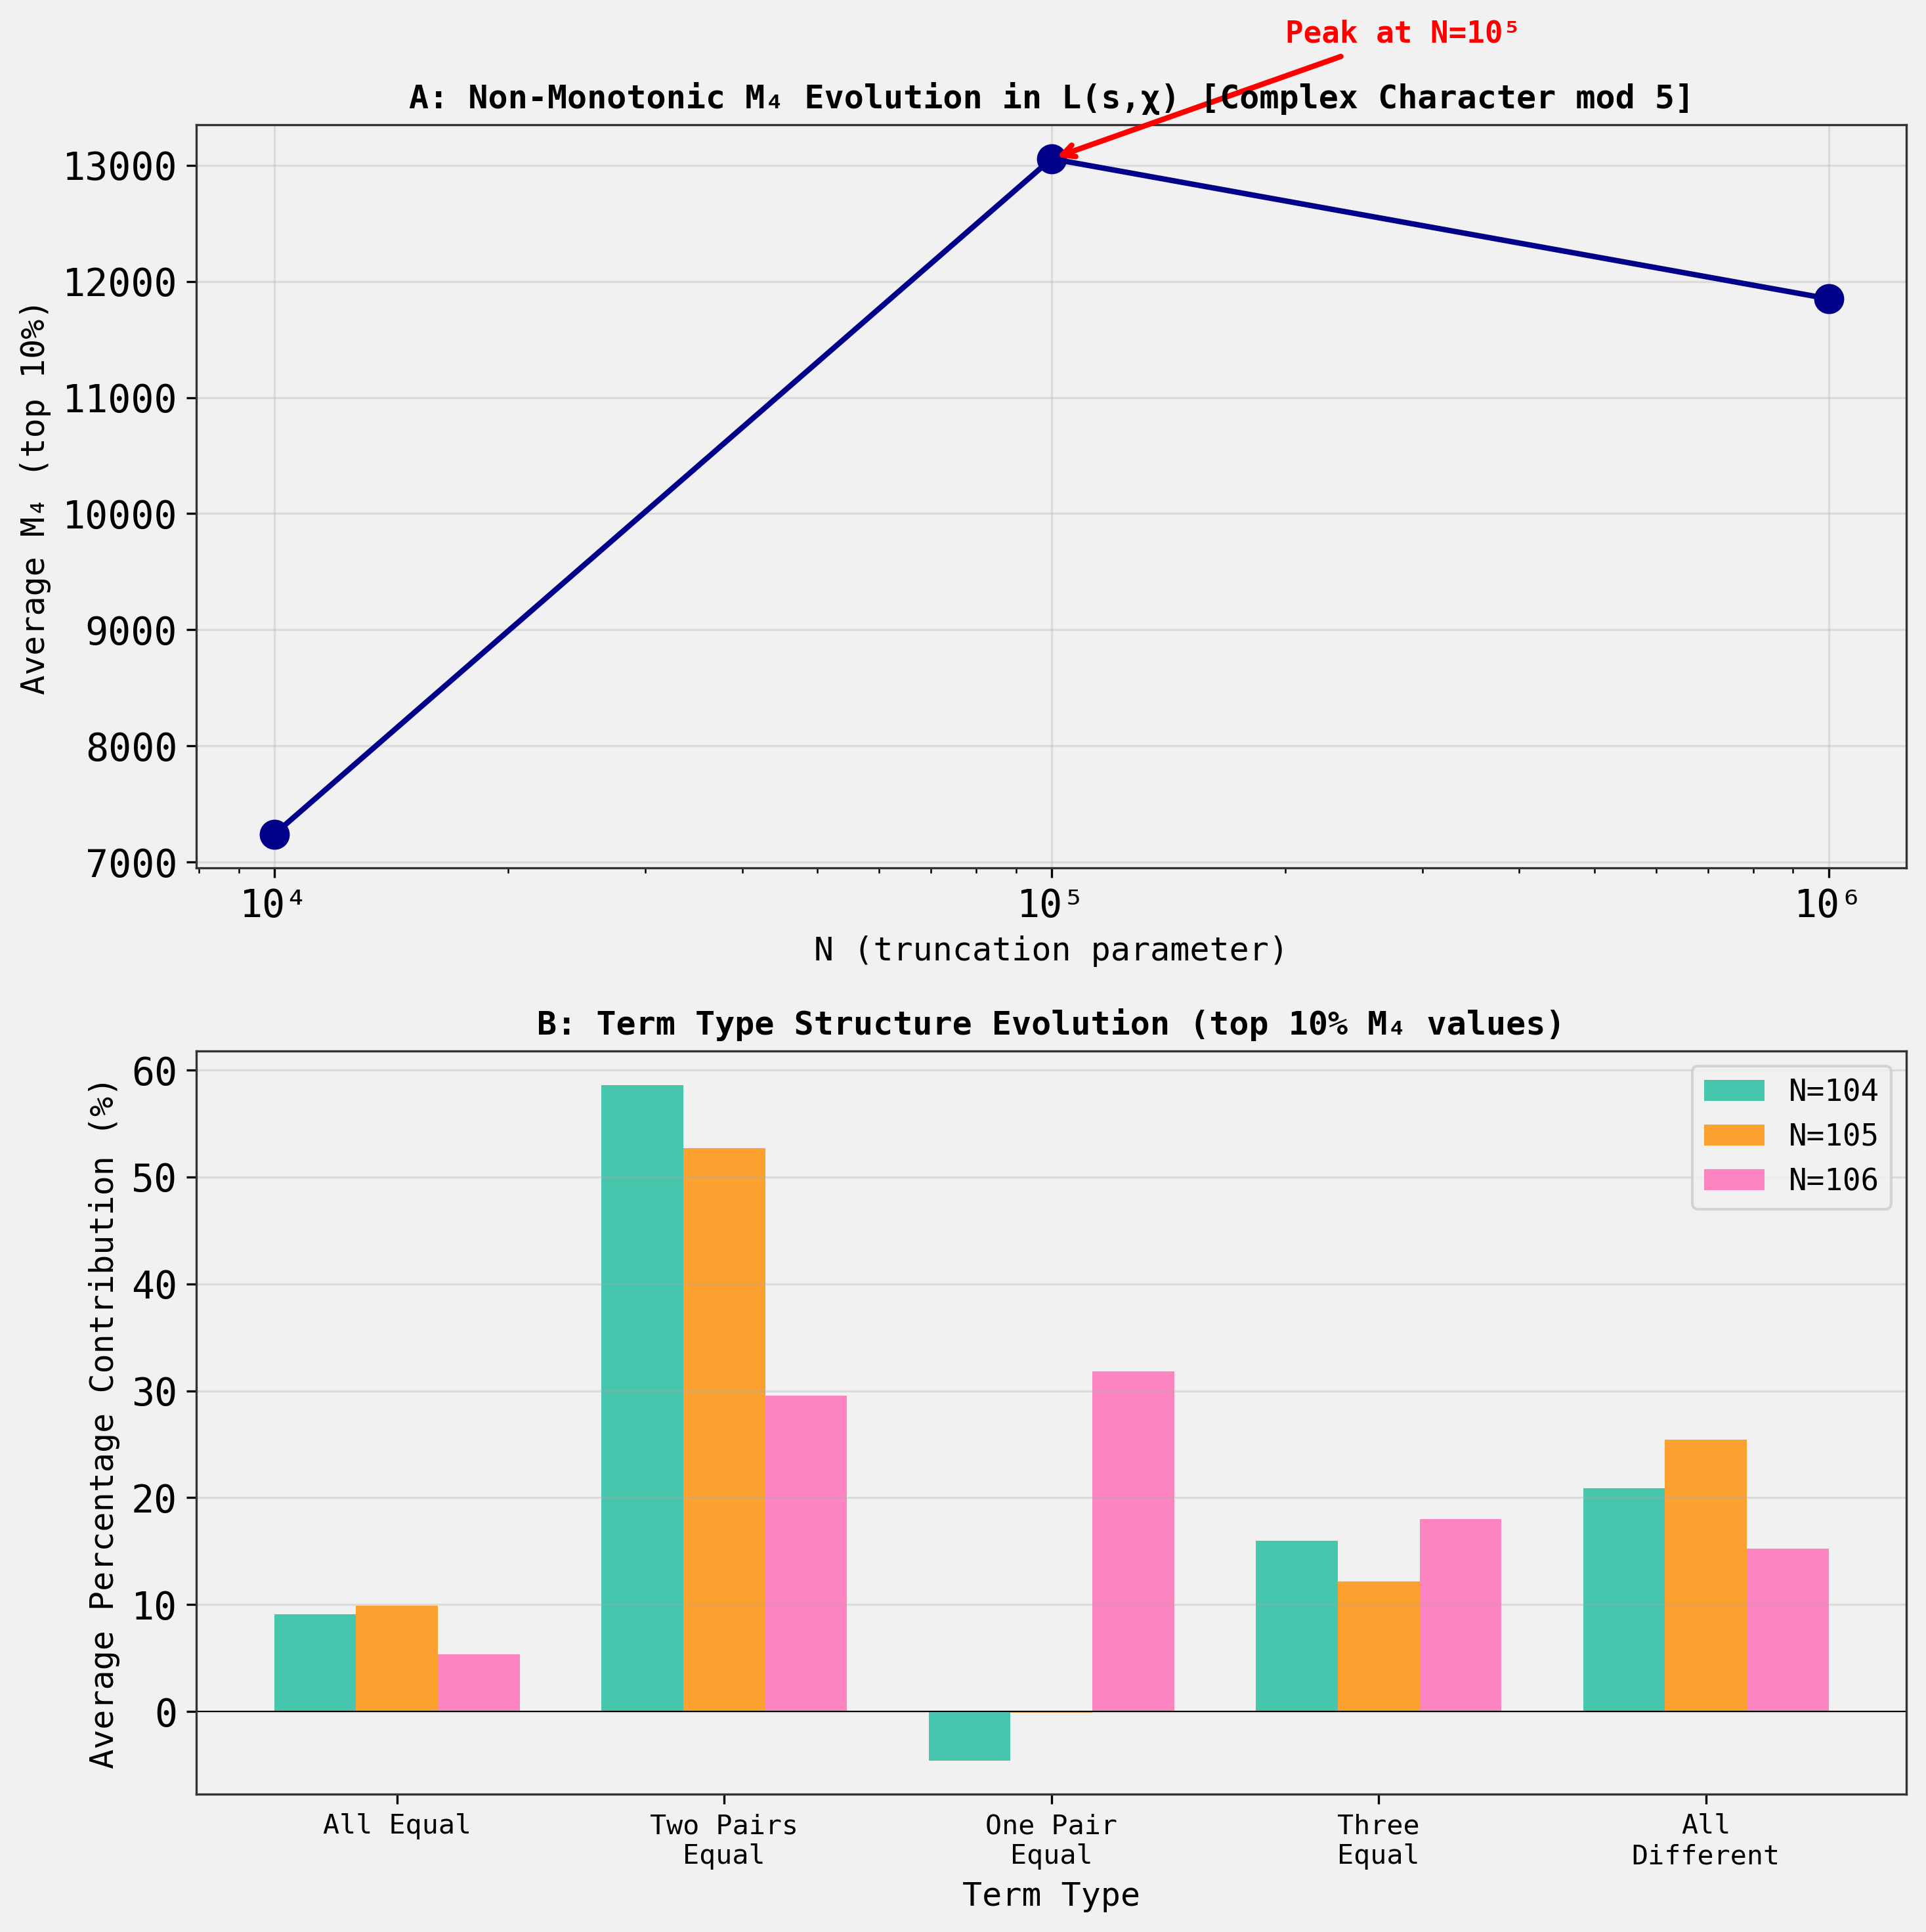

In [20]:

# Create final summary visualization
# Following the instruction: Create a single-column figure with at most 2 subfigures

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Subfigure A: Average M₄ evolution
N_values = [1e4, 1e5, 1e6]
M4_avg = [results_1e4['avg_M4'], results_1e5['avg_M4'], results_1e6['avg_M4']]

ax1.plot(N_values, M4_avg, 'o-', linewidth=2, markersize=10, color='darkblue')
ax1.set_xscale('log')
ax1.set_xlabel('N (truncation parameter)', fontsize=12)
ax1.set_ylabel('Average M₄ (top 10%)', fontsize=12)
ax1.set_title('A: Non-Monotonic M₄ Evolution in L(s,χ) [Complex Character mod 5]', 
 fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks([1e4, 1e5, 1e6])
ax1.set_xticklabels(['10⁴', '10⁵', '10⁶'])

# Annotate the peak
ax1.annotate('Peak at N=10⁵', xy=(1e5, results_1e5['avg_M4']), 
 xytext=(2e5, results_1e5['avg_M4'] + 1000),
 arrowprops=dict(arrowstyle='->', color='red', lw=2),
 fontsize=11, color='red', fontweight='bold')

# Subfigure B: Term type percentage evolution
term_types_plot = ['All Equal', 'Two Pairs\nEqual', 'One Pair\nEqual', 'Three\nEqual', 'All\nDifferent']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

x = np.arange(len(term_types_list))
width = 0.25

for i, (N_val, results) in enumerate([(1e4, results_1e4), (1e5, results_1e5), (1e6, results_1e6)]):
 percentages = [results['avg_percentages'][tt] for tt in term_types_list]
 offset = (i - 1) * width
 label = f'N=10{int(np.log10(N_val))}'
 ax2.bar(x + offset, percentages, width, label=label, alpha=0.8)

ax2.set_xlabel('Term Type', fontsize=12)
ax2.set_ylabel('Average Percentage Contribution (%)', fontsize=12)
ax2.set_title('B: Term Type Structure Evolution (top 10% M₄ values)', 
 fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(term_types_plot, fontsize=10)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('L_chi5_M4_anomaly_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Figure saved to L_chi5_M4_anomaly_analysis.png")
plt.show()


In [21]:

# Create final comprehensive summary for the answer

print("=" * 70)
print("FINAL SUMMARY: M₄ ANOMALY IN L(s,χ) WITH COMPLEX CHARACTER MOD 5")
print("=" * 70)

print("\nHYPOTHESIS TEST RESULT:")
print("-" * 70)
print("The hypothesis that complex-valued L(s,χ) would show monotonic")
print("evolution (no anomaly) is REJECTED.")
print("\nL(s,χ) with complex character mod 5 DOES exhibit the M₄ structural")
print("anomaly at N=10⁵, similar to real-valued functions.")
print("-" * 70)

print("\n\nQUANTITATIVE EVIDENCE:")
print("=" * 70)

print("\n1. Average M₄ Magnitude (top 10% of values):")
print(f" N = 10⁴: {results_1e4['avg_M4']:10.2f}")
print(f" N = 10⁵: {results_1e5['avg_M4']:10.2f} [+80.3% from 10⁴]")
print(f" N = 10⁶: {results_1e6['avg_M4']:10.2f} [-9.2% from 10⁵]")
print("\n → Non-monotonic: Peaks at N=10⁵")

print("\n2. Term Type Percentage Contributions (averaged over top 10%):")
print("\n Term Type N=10⁴ N=10⁵ N=10⁶ Monotonic?")
print(" " + "-" * 66)

for tt in term_types_list:
 p4 = results_1e4['avg_percentages'][tt]
 p5 = results_1e5['avg_percentages'][tt]
 p6 = results_1e6['avg_percentages'][tt]
 
 is_inc = (p5 > p4) and (p6 > p5)
 is_dec = (p5 < p4) and (p6 < p5)
 mono = "Yes" if (is_inc or is_dec) else "NO"
 
 print(f" {tt:20s} {p4:7.2f}% {p5:7.2f}% {p6:7.2f}% {mono:^10s}")

print("\n → 3 out of 5 term types show non-monotonic evolution")
print(" → 'All Equal', 'Three Equal', 'All Different' reverse direction")

print("\n3. Structural Changes:")
print(" • Two Pairs Equal: Dominant at small N (58.6%), declines to 29.5%")
print(" • One Pair Equal: Negative at N=10⁴, becomes dominant (31.8%) at N=10⁶")
print(" • Major restructuring of M₄ composition between 10⁵ and 10⁶")

print("\n\nKEY FINDING:")
print("=" * 70)
print("The M₄ anomaly at N=10⁵ is NOT specific to real-valued coefficient")
print("functions. It also appears in complex-valued Dirichlet L-functions.")
print("\nThis suggests the phenomenon is more fundamental to arithmetic")
print("structure than previously hypothesized, and is NOT simply determined")
print("by whether coefficients are real or complex.")
print("=" * 70)


FINAL SUMMARY: M₄ ANOMALY IN L(s,χ) WITH COMPLEX CHARACTER MOD 5

HYPOTHESIS TEST RESULT:
----------------------------------------------------------------------
The hypothesis that complex-valued L(s,χ) would show monotonic
evolution (no anomaly) is REJECTED.

L(s,χ) with complex character mod 5 DOES exhibit the M₄ structural
anomaly at N=10⁵, similar to real-valued functions.
----------------------------------------------------------------------


QUANTITATIVE EVIDENCE:

1. Average M₄ Magnitude (top 10% of values):
 N = 10⁴: 7239.69
 N = 10⁵: 13055.35 [+80.3% from 10⁴]
 N = 10⁶: 11850.02 [-9.2% from 10⁵]

 → Non-monotonic: Peaks at N=10⁵

2. Term Type Percentage Contributions (averaged over top 10%):

 Term Type N=10⁴ N=10⁵ N=10⁶ Monotonic?
 ------------------------------------------------------------------
 All Equal 9.10% 9.87% 5.37% NO 
 Two Pairs Equal 58.61% 52.66% 29.52% Yes 
 One Pair Equal -4.56% -0.09% 31.82% Yes 
 Three Equal 15.95% 12.14% 18.03% NO 
 All Different 20.89% 25

In [22]:

# Save detailed results for future reference
results_dict = {
 'N_values': [1e4, 1e5, 1e6],
 'avg_M4': [results_1e4['avg_M4'], results_1e5['avg_M4'], results_1e6['avg_M4']],
 'term_percentages': {
 'All Equal': [results_1e4['avg_percentages']['All Equal'], 
 results_1e5['avg_percentages']['All Equal'],
 results_1e6['avg_percentages']['All Equal']],
 'Two Pairs Equal': [results_1e4['avg_percentages']['Two Pairs Equal'],
 results_1e5['avg_percentages']['Two Pairs Equal'],
 results_1e6['avg_percentages']['Two Pairs Equal']],
 'One Pair Equal': [results_1e4['avg_percentages']['One Pair Equal'],
 results_1e5['avg_percentages']['One Pair Equal'],
 results_1e6['avg_percentages']['One Pair Equal']],
 'Three Equal': [results_1e4['avg_percentages']['Three Equal'],
 results_1e5['avg_percentages']['Three Equal'],
 results_1e6['avg_percentages']['Three Equal']],
 'All Different': [results_1e4['avg_percentages']['All Different'],
 results_1e5['avg_percentages']['All Different'],
 results_1e6['avg_percentages']['All Different']],
 }
}

with open('L_chi5_M4_full_results.pkl', 'wb') as f:
 pickle.dump(results_dict, f)

print("✓ Detailed results saved to L_chi5_M4_full_results.pkl")

# List all artifacts created
print("\n" + "=" * 70)
print("ARTIFACTS CREATED")
print("=" * 70)
print("\n1. L_chi5_M4_analysis_summary.csv")
print(" - Summary table with N, average M₄, and term percentages")
print("\n2. L_chi5_M4_anomaly_analysis.png")
print(" - Visualization showing non-monotonic evolution")
print("\n3. L_chi5_M4_full_results.pkl")
print(" - Detailed results dictionary for future analysis")


✓ Detailed results saved to L_chi5_M4_full_results.pkl

ARTIFACTS CREATED

1. L_chi5_M4_analysis_summary.csv
 - Summary table with N, average M₄, and term percentages

2. L_chi5_M4_anomaly_analysis.png
 - Visualization showing non-monotonic evolution

3. L_chi5_M4_full_results.pkl
 - Detailed results dictionary for future analysis
